# **Evaluation**

This notebook evaluates the model by checking its performance on species classifcation performance and analyzes its ability to detect shiny versions.

In [2]:
# Imports
import os
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from collections import Counter
from IPython.display import display
from models import get_model, get_device
from PIL import Image
from pokenet.dataloader import PokemonDataset, data_transform, get_data_loaders
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

## **Setup**

In [3]:
# Download dataset from Kagglehub
import kagglehub

path = kagglehub.dataset_download("noodulz/pokemon-dataset-1000")
print("Path to dataset files:", path)

Path to dataset files: /home/mzhan/.cache/kagglehub/datasets/noodulz/pokemon-dataset-1000/versions/2


In [4]:
# Setup
base_path = os.path.join(path, "pokemon-dataset-1000")

# Get device and test loader for evaluation
device = get_device()
train_loader, val_loader, test_loader = get_data_loaders(base_path, batch_size = 5)

In [5]:
# Load model
model = get_model()
model.load_state_dict(torch.load("../pokenet_best.pth", map_location = device, weights_only = True))
model = model.to(device)
model.eval()
print("Model loaded successfully")

Model loaded successfully


## **Species Classification Metrics**

I intend on using essential classification metrics, specifically calculating the F1 score and visualizing a confusion matrix, to evaluate my model. The F1-score balances both precision and recall and will be especially useful when classifying the shiny alternative, as the normal-to-shiny ratio is uneven. However, this evaluation is more exploratory, since we are not explicitly training for shiny detection.

In [12]:
def get_all_predictions(model, dataloader, device):
    '''
    Collects all predictions and true labels across the entire test set

    Args:
    model (nn.Module): ResNet50 model
    dataloader (DataLoader): Dataloader for test data
    device (torch.device): GPU or CPU, depending on availability
    '''
    all_predictions = []
    all_labels = []

    # Set the model to evaluation mode
    model.eval()

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    return all_predictions, all_labels

all_predictions, all_labels = get_all_predictions(model, test_loader, device)
print(f"Total predictions: {len(all_predictions)}")  # Check if predictions match number of images in test set

# F1 score
f1 = f1_score(all_labels, all_predictions, average = "macro")
print(f"Macro F1 score: {f1}")

Total predictions: 3239
Macro F1 score: 0.8959444888444889


I will also be listing the top five accuraccies, which may be beneficial given the scale of my classification task. Although accuracy is not always the most reliable, listing the top five can provide more details on how the model was trained, as opposed to a single and potentially biased score.

In [7]:
def get_top5_accuracy(model, dataloader, device):
    '''
    Compute accuracy if the correct prediction was in the model's top 5 guesses
    
    Args:
    model (nn.Module): ResNet50 model
    dataloader (DataLoader): Dataloader for test data
    device (torch.device): GPU or CPU, depending on availability
    '''
    total_correct = 0
    total_samples = 0
    top5_guesses = []
    index_to_species = {index: label for label, index in dataloader.dataset.species_to_index.items()}

    # Set the model to evaluation mode
    model.eval()
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, top5_predicted = torch.topk(outputs, k = 5, dim = 1)  # Top 5 predictions for each image
            # Check if the true label is in the top 5 accuracies
            for i in range(len(labels)):
                if labels[i] in top5_predicted[i]:
                    total_correct += 1
                top5_names = [index_to_species[idx.item()] for idx in top5_predicted[i]]
                top5_guesses.append({
                    "true": index_to_species[labels[i].item()],
                    "top 5": top5_names,
                    "correct": labels[i].item() in [idx.item() for idx in top5_predicted[i]]
                })
            total_samples += labels.size(0)

    return total_correct / total_samples, top5_guesses

top5_accuracy, top5_guesses = get_top5_accuracy(model, test_loader, device)
print(f"Top 5 accuracy: {top5_accuracy}")

# Show first 5 examples
for result in top5_guesses[:5]:
    print(f"True: {result['true']}")
    print(f"Top 5: {result['top 5']}")
    print(f"Correct: {result['correct']}\n")

Top 5 accuracy: 0.9536894103118246
True: abomasnow
Top 5: ['abomasnow', 'snover', 'kyurem', 'cursola', 'baxcalibur']
Correct: True

True: abomasnow
Top 5: ['abomasnow', 'snover', 'beartic', 'glastrier', 'regidrago']
Correct: True

True: abomasnow
Top 5: ['abomasnow', 'glastrier', 'beartic', 'snover', 'vanilluxe']
Correct: True

True: abomasnow
Top 5: ['abomasnow', 'lapras', 'walrein', 'primarina', 'vanilluxe']
Correct: True

True: abra
Top 5: ['drowzee', 'parasect', 'furret', 'sunflora', 'misdreavus']
Correct: False



## **Comparison**

In [11]:
# Evaluate performance of best model checkpoint vs. final model checkpoint
results = {}
for weights_file in ["../pokenet.pth", "../pokenet_best.pth"]:
    model = get_model().to(device)
    model.load_state_dict(torch.load(weights_file, map_location = device, weights_only = True))
    model.eval()
    
    # Top 5 accuracy
    top_5, top5_guesses = get_top5_accuracy(model, test_loader, device)
    
    # F1 score
    preds, labels = get_all_predictions(model, test_loader, device)
    f1 = f1_score(labels, preds, average = "macro")
    
    results[weights_file] = {"Top 5 Accuracy": top_5, "Macro F1": f1}
    print(f"\n{weights_file}:")
    print(f"Top 5 Accuracy: {top_5}")
    print(f"Macro F1: {f1}")


../pokenet.pth:
Top 5 Accuracy: 0.9536894103118246
Macro F1: 0.8959444888444889

../pokenet_best.pth:
Top 5 Accuracy: 0.9536894103118246
Macro F1: 0.8959444888444889


The identical accuracy and F1 scores indicate that the final model checkpoint was, in fact, the best model checkpoint. Validation loss continued to improve even with 50 epochs during Phase 2 training. Early stopping was never triggered, suggesting that additional epochs could be added to help the model converge and potentially improve performance.

## **Confusion**

A confusion matrix will be used to focus on the species the model gets wrong most often. Because 1000 classes would make the matrix difficult to interpret and visualize, I will focus on the most confused species.

In [32]:
index_to_species = {index: label for label, index in test_loader.dataset.species_to_index.items()}

# Count errors per species
errors = []
for label, prediction in zip(all_labels, all_predictions):
    if label != prediction:
        errors.append((index_to_species[label], index_to_species[prediction]))

most_confused = Counter([true for true, predictions in errors]).most_common(20)
print("Most Confused Species")
for species, count in most_confused:
    print(f"\nSpecies: {species} | Errors: {count}")

Most Confused Species

Species: beedrill | Errors: 4

Species: abra | Errors: 3

Species: barboach | Errors: 3

Species: corphish | Errors: 3

Species: graveler | Errors: 3

Species: hitmonlee | Errors: 3

Species: kangaskhan | Errors: 3

Species: komala | Errors: 3

Species: metagross | Errors: 3

Species: moltres | Errors: 3

Species: monferno | Errors: 3

Species: parasect | Errors: 3

Species: sableye | Errors: 3

Species: sandslash | Errors: 3

Species: squirtle | Errors: 3

Species: vaporeon | Errors: 3

Species: xurkitree | Errors: 3

Species: anorith | Errors: 2

Species: bagon | Errors: 2

Species: banette | Errors: 2


Filtered samples: 85


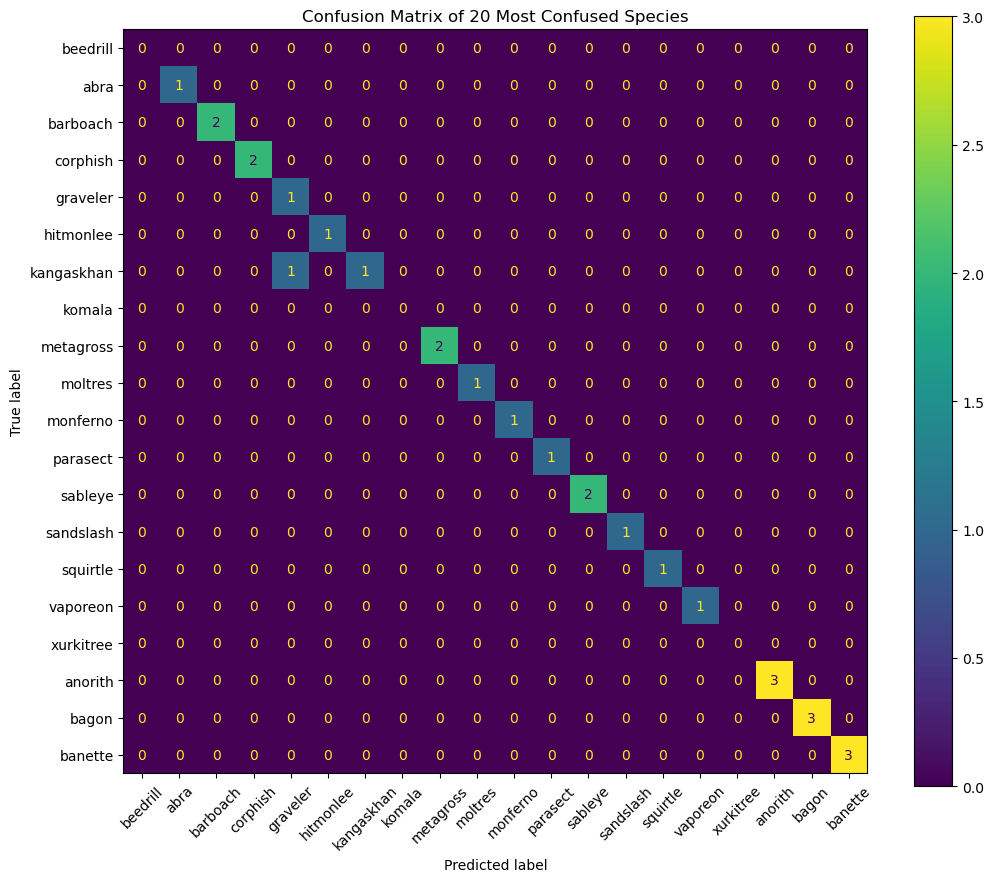

In [72]:
# Get the names and indices of the 20 most confused species
most_confused_species = [species for species, count in most_confused]
most_confused_indices = [test_loader.dataset.species_to_index[species] for species in most_confused_species]

# Filter predictions and labels to only include these species
filtered_labels = []
filtered_predictions = []

for label, prediction in zip(all_labels, all_predictions):
    if label in most_confused_indices:
        filtered_labels.append(label)
        filtered_predictions.append(prediction)

print(f"Filtered samples: {len(filtered_labels)}")

# Build confusion matrix
matrix = confusion_matrix(filtered_labels, filtered_predictions, labels = most_confused_indices)

# Plot
fig, ax = plt.subplots(figsize = (12, 10))
display = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels = most_confused_species)
display.plot(ax = ax, xticks_rotation = 45)
plt.title("Confusion Matrix of 20 Most Confused Species")
plt.savefig("../results/confusion_matrix.png")
plt.show()

Diagonal values represent correct predictions. Values that are not along the diagonal represent misclassifications. Based on the confusion matrix, we observe that Kangaskhan was once predicted as Graveler. Values towards the bottom indicate fewer errors than the species above them, which we can see was the case for Anorith, Bagon, and Banette.

## **Sample Predictions Visualization**

Now that we have identified the most misclassified species, I will display a grid of test images with true and predicted labels.

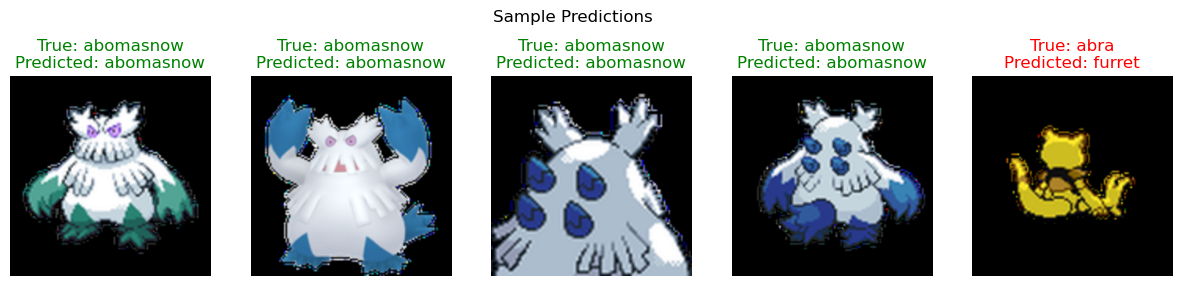

In [73]:
# Get a batch of test images
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# Obtain predictions
with torch.no_grad():
    output = model(images)
    _, predicted = torch.max(output, 1)

# Undo normalization
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

plot_images = images.cpu() * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)
plot_images = plot_images.numpy().transpose(0, 2, 3, 1).clip(0, 1)
plot_images = (plot_images * 255.0).astype(np.uint8)

# Plot grid
fig, axes = plt.subplots(1, 5, figsize = (15, 3))

for i, ax in enumerate(axes):
    true_label = index_to_species[labels[i].item()]
    color = "green" if labels[i].item() == predicted[i].item() else "red"
    predicted_label = index_to_species[predicted[i].item()]
    ax.imshow(plot_images[i])
    ax.set_title(f"True: {true_label}\nPredicted: {predicted_label}", color = color)
    ax.axis("off")

plt.suptitle("Sample Predictions", y = 1.05)
plt.savefig("../results/sample_predictions.png")
plt.show()

Labels in green represent correct predictions, while those in red represents misclassification. The model correctly identifies Abomasnow in four different art styles, including the normal and shiny versions. It also correctly identifies it even with its back turned, showing strong shape-detection and feature-extraction capabilities. However, it misidentifies Abra as Furret.

## **Shiny Detection Analysis**

To take my project a step further, I tested its ability to differentiate a Pokémon from its shiny version versus its original form. Since none of the shiny variations had ground truth labels indicating as such, I was unable to explicitly ask if a species was shiny or not. Instead, I manually identified the shiny versions first, then tested the model's confidence in predicting the species. My hypothesis was that the model was less confident when looking at the shiny version because the colors were different and would be higher if the versions were harder to distinguish.

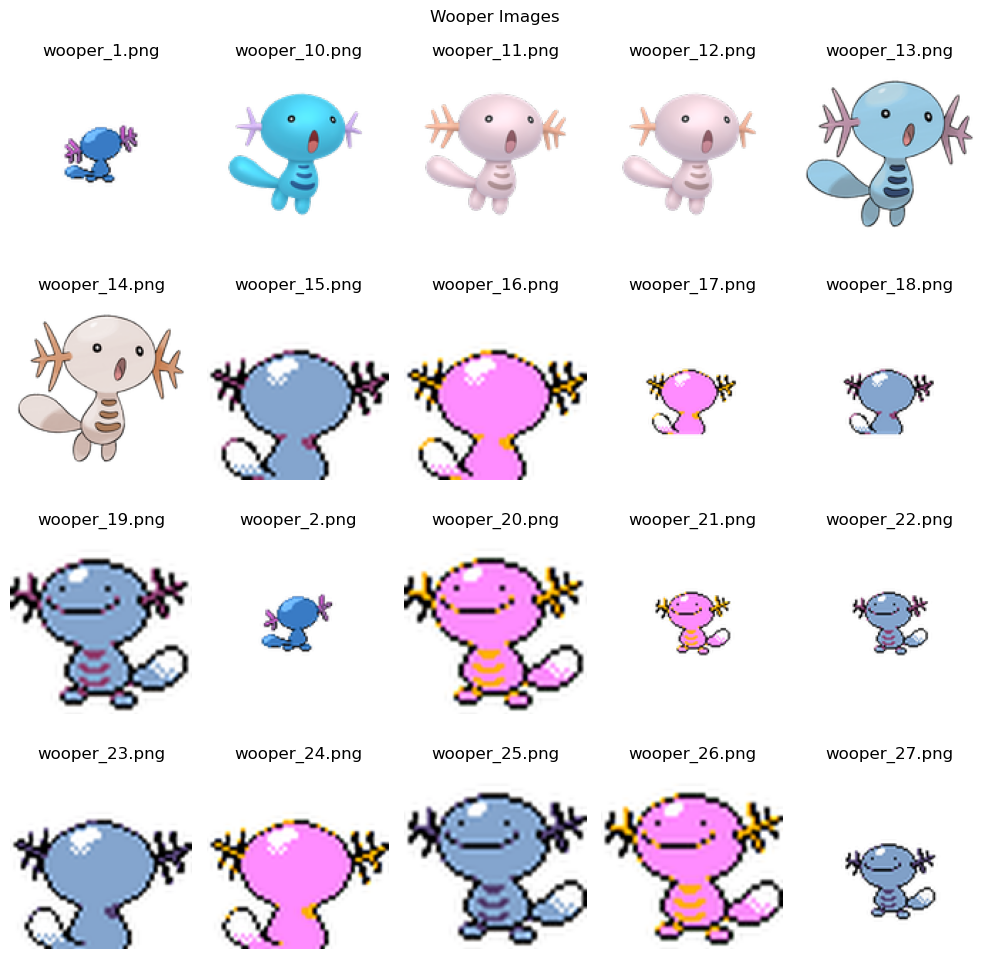

In [104]:
# Plot Wooper images
wooper = os.path.join(path, "pokemon-dataset-1000", "dataset", "wooper")
wooper_files = sorted(os.listdir(wooper))

fig, axes = plt.subplots(4, 5, figsize = (10, 10))
for i, ax in enumerate(axes.flatten()):
    if i < len(wooper_files):
        image = PILImage.open(os.path.join(wooper, wooper_files[i]))
        ax.imshow(image)
        ax.set_title(wooper_files[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.suptitle("Wooper Images")
plt.tight_layout()
plt.show()

In [130]:
# Shiny vs. normal Woopers
normal_wooper = [
    os.path.join(wooper, "wooper_1.png"),
    os.path.join(wooper, "wooper_10.png"),
    os.path.join(wooper, "wooper_13.png"),
    os.path.join(wooper, "wooper_15.png"),
    os.path.join(wooper, "wooper_18.png"),
    os.path.join(wooper, "wooper_19.png"),
    os.path.join(wooper, "wooper_2.png"),
    os.path.join(wooper, "wooper_22.png"),
    os.path.join(wooper, "wooper_23.png"),
    os.path.join(wooper, "wooper_25.png"),
    os.path.join(wooper, "wooper_27.png")
]

shiny_wooper = [
    os.path.join(wooper, "wooper_11.png"),
    os.path.join(wooper, "wooper_12.png"),
    os.path.join(wooper, "wooper_14.png"),
    os.path.join(wooper, "wooper_16.png"),
    os.path.join(wooper, "wooper_17.png"),
    os.path.join(wooper, "wooper_20.png"),
    os.path.join(wooper, "wooper_21.png"),
    os.path.join(wooper, "wooper_24.png"),
    os.path.join(wooper, "wooper_26.png")
]

transform = data_transform(image_size = 256)

def get_confidence(image_path, model, transform, device):
    '''
    Returns a predicted species and confidence score for a single image

    Args:
    image_path (str): Path to image file
    model (nn.Module): Trained model
    transform: Preprocessing transform
    device (torch.device): GPU or CPU, depending on availability
    '''
    image = PILImage.open(image_path).convert("RGB")
    image = transform(image)
    image = image.unsqueeze(0).to(device)  # Add batch dimension
    with torch.no_grad():
        output = model(image)
        probabilities = F.softmax(output, dim = 1)
        confidence, predicted = torch.max(probabilities, 1)

    return predicted.item(), confidence.item()

# Prediction and confidence score for normal and shiny versions
normal_wooper_confidence = []
for image_path in normal_wooper:
    prediction, confidence = get_confidence(image_path, model, transform, device)
    normal_wooper_confidence.append(confidence)

shiny_wooper_confidence = []
for image_path in shiny_wooper:
    prediction, confidence = get_confidence(image_path, model, transform, device)
    shiny_wooper_confidence.append(confidence)

print(f"Average normal confidence (Wooper): {np.mean(normal_wooper_confidence)}")
print(f"Average shiny confidence (Wooper): {np.mean(shiny_wooper_confidence)}")

Average normal confidence (Wooper): 0.9980157938870516
Average shiny confidence (Wooper): 0.9972559412320455


We will repeat the same process with Garchomp, a Pokémon whose normal and shiny versions are notoriously known to be difficult to distinguish.

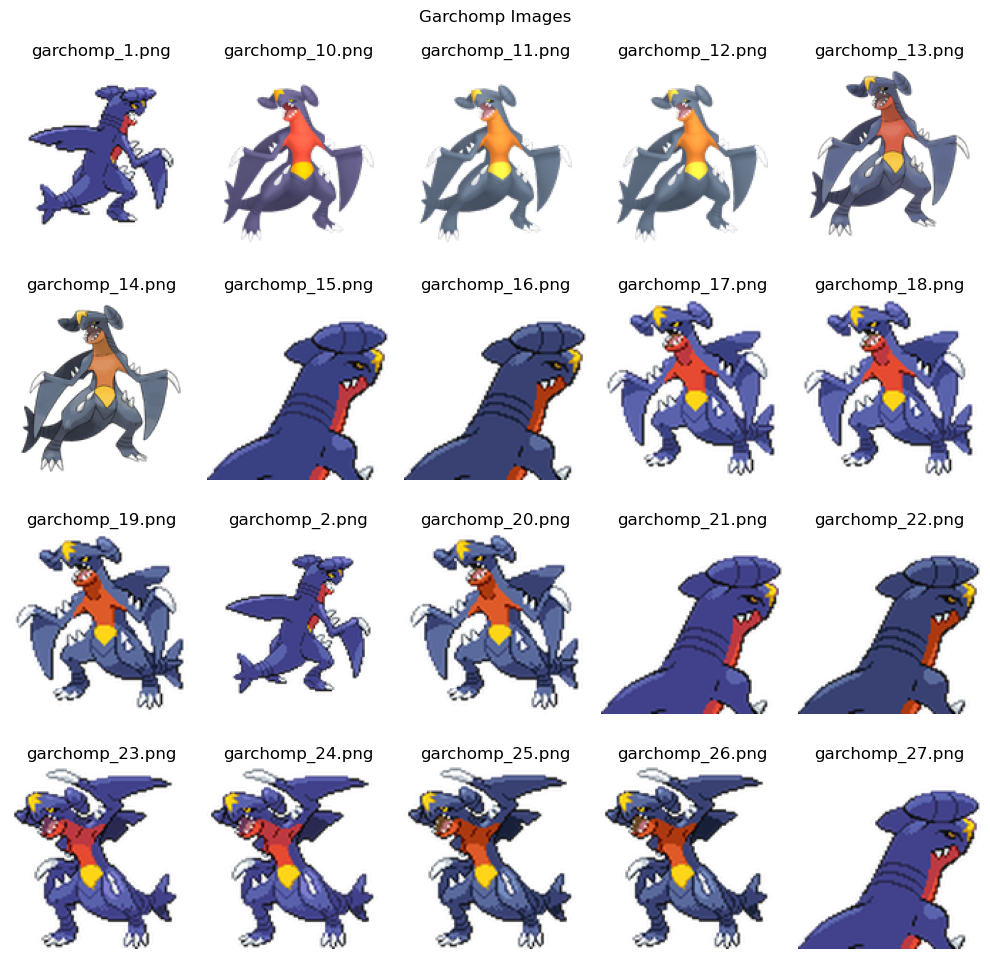

In [129]:
# Plot Gengar images
garchomp = os.path.join(path, "pokemon-dataset-1000", "dataset", "garchomp")
garchomp_files = sorted(os.listdir(garchomp))

fig, axes = plt.subplots(4, 5, figsize = (10, 10))
for i, ax in enumerate(axes.flatten()):
    if i < len(garchomp_files):
        image = PILImage.open(os.path.join(garchomp, garchomp_files[i]))
        ax.imshow(image)
        ax.set_title(garchomp_files[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.suptitle("Garchomp Images")
plt.tight_layout()
plt.show()

In [132]:
# Shiny vs. normal Garchomp
normal_garchomp = [
    os.path.join(garchomp, "garchomp_1.png"),
    os.path.join(garchomp, "garchomp_10.png"),
    os.path.join(garchomp, "garchomp_13.png"),
    os.path.join(garchomp, "garchomp_15.png"),
    os.path.join(garchomp, "garchomp_17.png"),
    os.path.join(garchomp, "garchomp_18.png"),
    os.path.join(garchomp, "garchomp_2.png"),
    os.path.join(garchomp, "garchomp_21.png"),
    os.path.join(garchomp, "garchomp_23.png"),
    os.path.join(garchomp, "garchomp_24.png"),
    os.path.join(garchomp, "garchomp_27.png")
]

shiny_garchomp = [
    os.path.join(garchomp, "garchomp_11.png"),
    os.path.join(garchomp, "garchomp_12.png"),
    os.path.join(garchomp, "garchomp_14.png"),
    os.path.join(garchomp, "garchomp_16.png"),
    os.path.join(garchomp, "garchomp_19.png"),
    os.path.join(garchomp, "garchomp_20.png"),
    os.path.join(garchomp, "garchomp_22.png"),
    os.path.join(garchomp, "garchomp_25.png"),
    os.path.join(garchomp, "garchomp_26.png"),
]

# Prediction and confidence score for normal and shiny versions
normal_garchomp_confidence = []
for image_path in normal_garchomp:
    prediction, confidence = get_confidence(image_path, model, transform, device)
    normal_garchomp_confidence.append(confidence)

shiny_garchomp_confidence = []
for image_path in shiny_garchomp:
    prediction, confidence = get_confidence(image_path, model, transform, device)
    shiny_garchomp_confidence.append(confidence)

print(f"Average normal confidence (Garchomp): {np.mean(normal_garchomp_confidence)}")
print(f"Average shiny confidence (Garchomp): {np.mean(shiny_garchomp_confidence)}")

Average normal confidence (Garchomp): 0.9988322908228094
Average shiny confidence (Garchomp): 0.9848987658818563


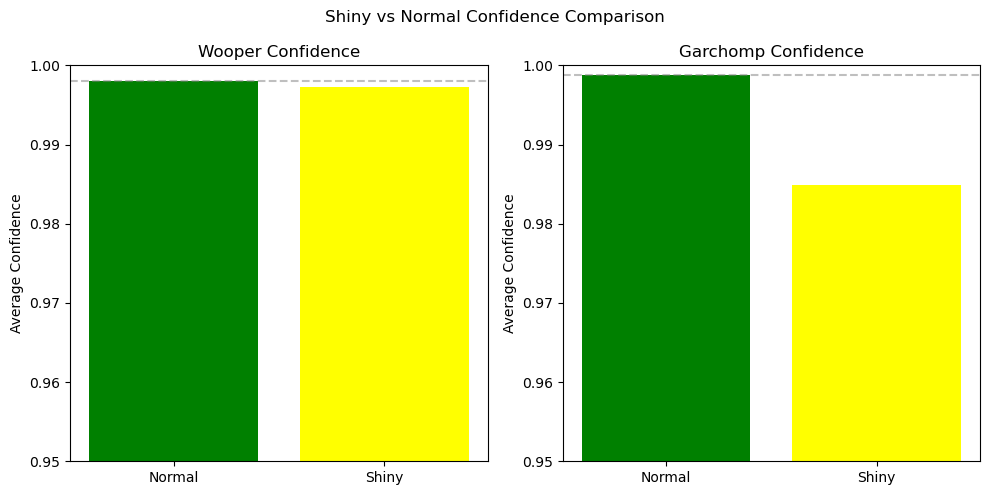

In [137]:
# Compare both Pokémon and their results
fig, axes = plt.subplots(1, 2, figsize = (10, 5))

for ax, (species, normal_confidence, shiny_confidence) in zip(axes, [
    ("Wooper", np.mean(normal_wooper_confidence), np.mean(shiny_wooper_confidence)),
    ("Garchomp", np.mean(normal_garchomp_confidence), np.mean(shiny_garchomp_confidence))
]):
    ax.bar(["Normal", "Shiny"], [normal_confidence, shiny_confidence], color = ["green", "yellow"])
    ax.set_title(f"{species} Confidence")
    ax.set_ylabel("Average Confidence")
    ax.set_ylim(0.95, 1.0)
    ax.axhline(y = normal_confidence, color = "gray", linestyle = "--", alpha = 0.5)

plt.suptitle("Shiny vs Normal Confidence Comparison")
plt.tight_layout()
plt.savefig("../results/shiny_confidence.png", bbox_inches = "tight")
plt.show()

The confidence gap in identifying Garchomp is slightly larger than identifying Wooper. Across both Pokémon, the model appears to correctly identify the species majority of the time, and confidence in identifying the shiny versions is slightly less than identifying normal versions.